# Assignment 01: Exploratory Data Analysis & Data Preprocessing
### Seasons of Code - AnimAI
---
## Introduction

Welcome to your first assignment for the AnimAI project! In this assignment, you'll work with a dataset containing popularity statistics for various cartoon characters across different countries. This dataset has intentionally been made "messy" with outliers, missing values, and inconsistencies to simulate real-world data challenges.

The skills you learn in this assignment will form the foundation for more advanced machine learning and AI applications in later weeks of the project.

>**Objective**: To perform exploratory data analysis and preprocessing on a cartoon character popularity dataset, applying fundamental concepts of data cleaning, visualization, and statistical analysis.


## Dataset Overview

The dataset `cartoon_popularity_data.csv` contains information about cartoon character popularity across various countries with the following columns:

- `Character`: Name of the cartoon character
- `Country`: Country where the popularity was measured
- `Popularity_Score`: A rating from 0-100 indicating popularity (though some entries may fall outside this range)
- `Avg_Episodes_Watched_Per_Year`: Average number of episodes watched per viewer per year
- `Merchandise_Revenue_MillionUSD`: Revenue generated from character merchandise in millions of USD

First, let's import the necessary libraries and load our dataset:

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set figure size for better readability
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

# Load the dataset
file_path = 'cartoon_popularity_data.csv' # Fill here with the path to your dataset

# Check if the file exists
try:
    with open(file_path, 'r') as f:
        pass
except FileNotFoundError:
    print(f"File {file_path} not found. Please check the path and try again.")
    exit()

# Read the dataset
df = pd.read_csv(file_path)

# Display the first few rows
print(f"Dataset shape: {df.shape}")
df.head(100)

Dataset shape: (10000, 5)


,Character,Country,Popularity_Score,Avg_Episodes_Watched_Per_Year,Merchandise_Revenue_MillionUSD
0,Shinchan,Canada,74.06677446676758,80,3.949924724368964
1,Paw Patrol,France,80.58192518328079,48,22.31606244865129
2,SpongeBob SquarePants,Russia,37.853437720835345,127.5,258.92694939230086
3,Motu Patlu,UK,83.41104266407503,50,27.430804382862224
4,Mr Bean,Egypt,76.83135775923722,9,40.715313915210565
...,...,...,...,...,...
95,Paw Patrol,Australia,25.000321158900707,52,11.156383443092526
96,Motu Patlu,South Korea,81.67032558555005,8,40.24894258155453
97,SpongeBob SquarePants,Italy,28.687939731326818,141.0,228.37582296538534
98,Mr Bean,UAE,28.810157803923055,11,64.25622148510823


## Part 1: Exploratory Data Analysis (EDA)

### Task 1.1: Basic Data Exploration

- Display the shape of the dataset
- Check the data types of each column
- Generate basic statistics using `describe()`
- Check for missing values in each column

In [3]:
# TODO: Your code here
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())

(10000, 5)
Character                         object
Country                           object
Popularity_Score                  object
Avg_Episodes_Watched_Per_Year     object
Merchandise_Revenue_MillionUSD    object
dtype: object
       Character    Country Popularity_Score Avg_Episodes_Watched_Per_Year  \
count      10000       9553             9558                          9933   
unique        50         41             9488                           492   
top     Doraemon  Australia          Unknown                            13   
freq         929        430               71                            93   

       Merchandise_Revenue_MillionUSD  
count                           10000  
unique                          10000  
top                 3.949924724368964  
freq                                1  
Character                           0
Country                           447
Popularity_Score                  442
Avg_Episodes_Watched_Per_Year      67
Merchandise_Revenue_Million

### Task 1.2: Data Visualization

Create appropriate visualizations to explore the dataset:

1. Distribution of popularity scores (histogram)
2. Average episodes watched by character (bar chart)
3. Merchandise revenue by country (box plot)
4. Correlation heatmap between numerical variables

/var/folders/l7/4qmv1ff116nbd017vb1kny5r0000gn/T/ipykernel_13563/4217267010.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(data_by_country, labels=countries)


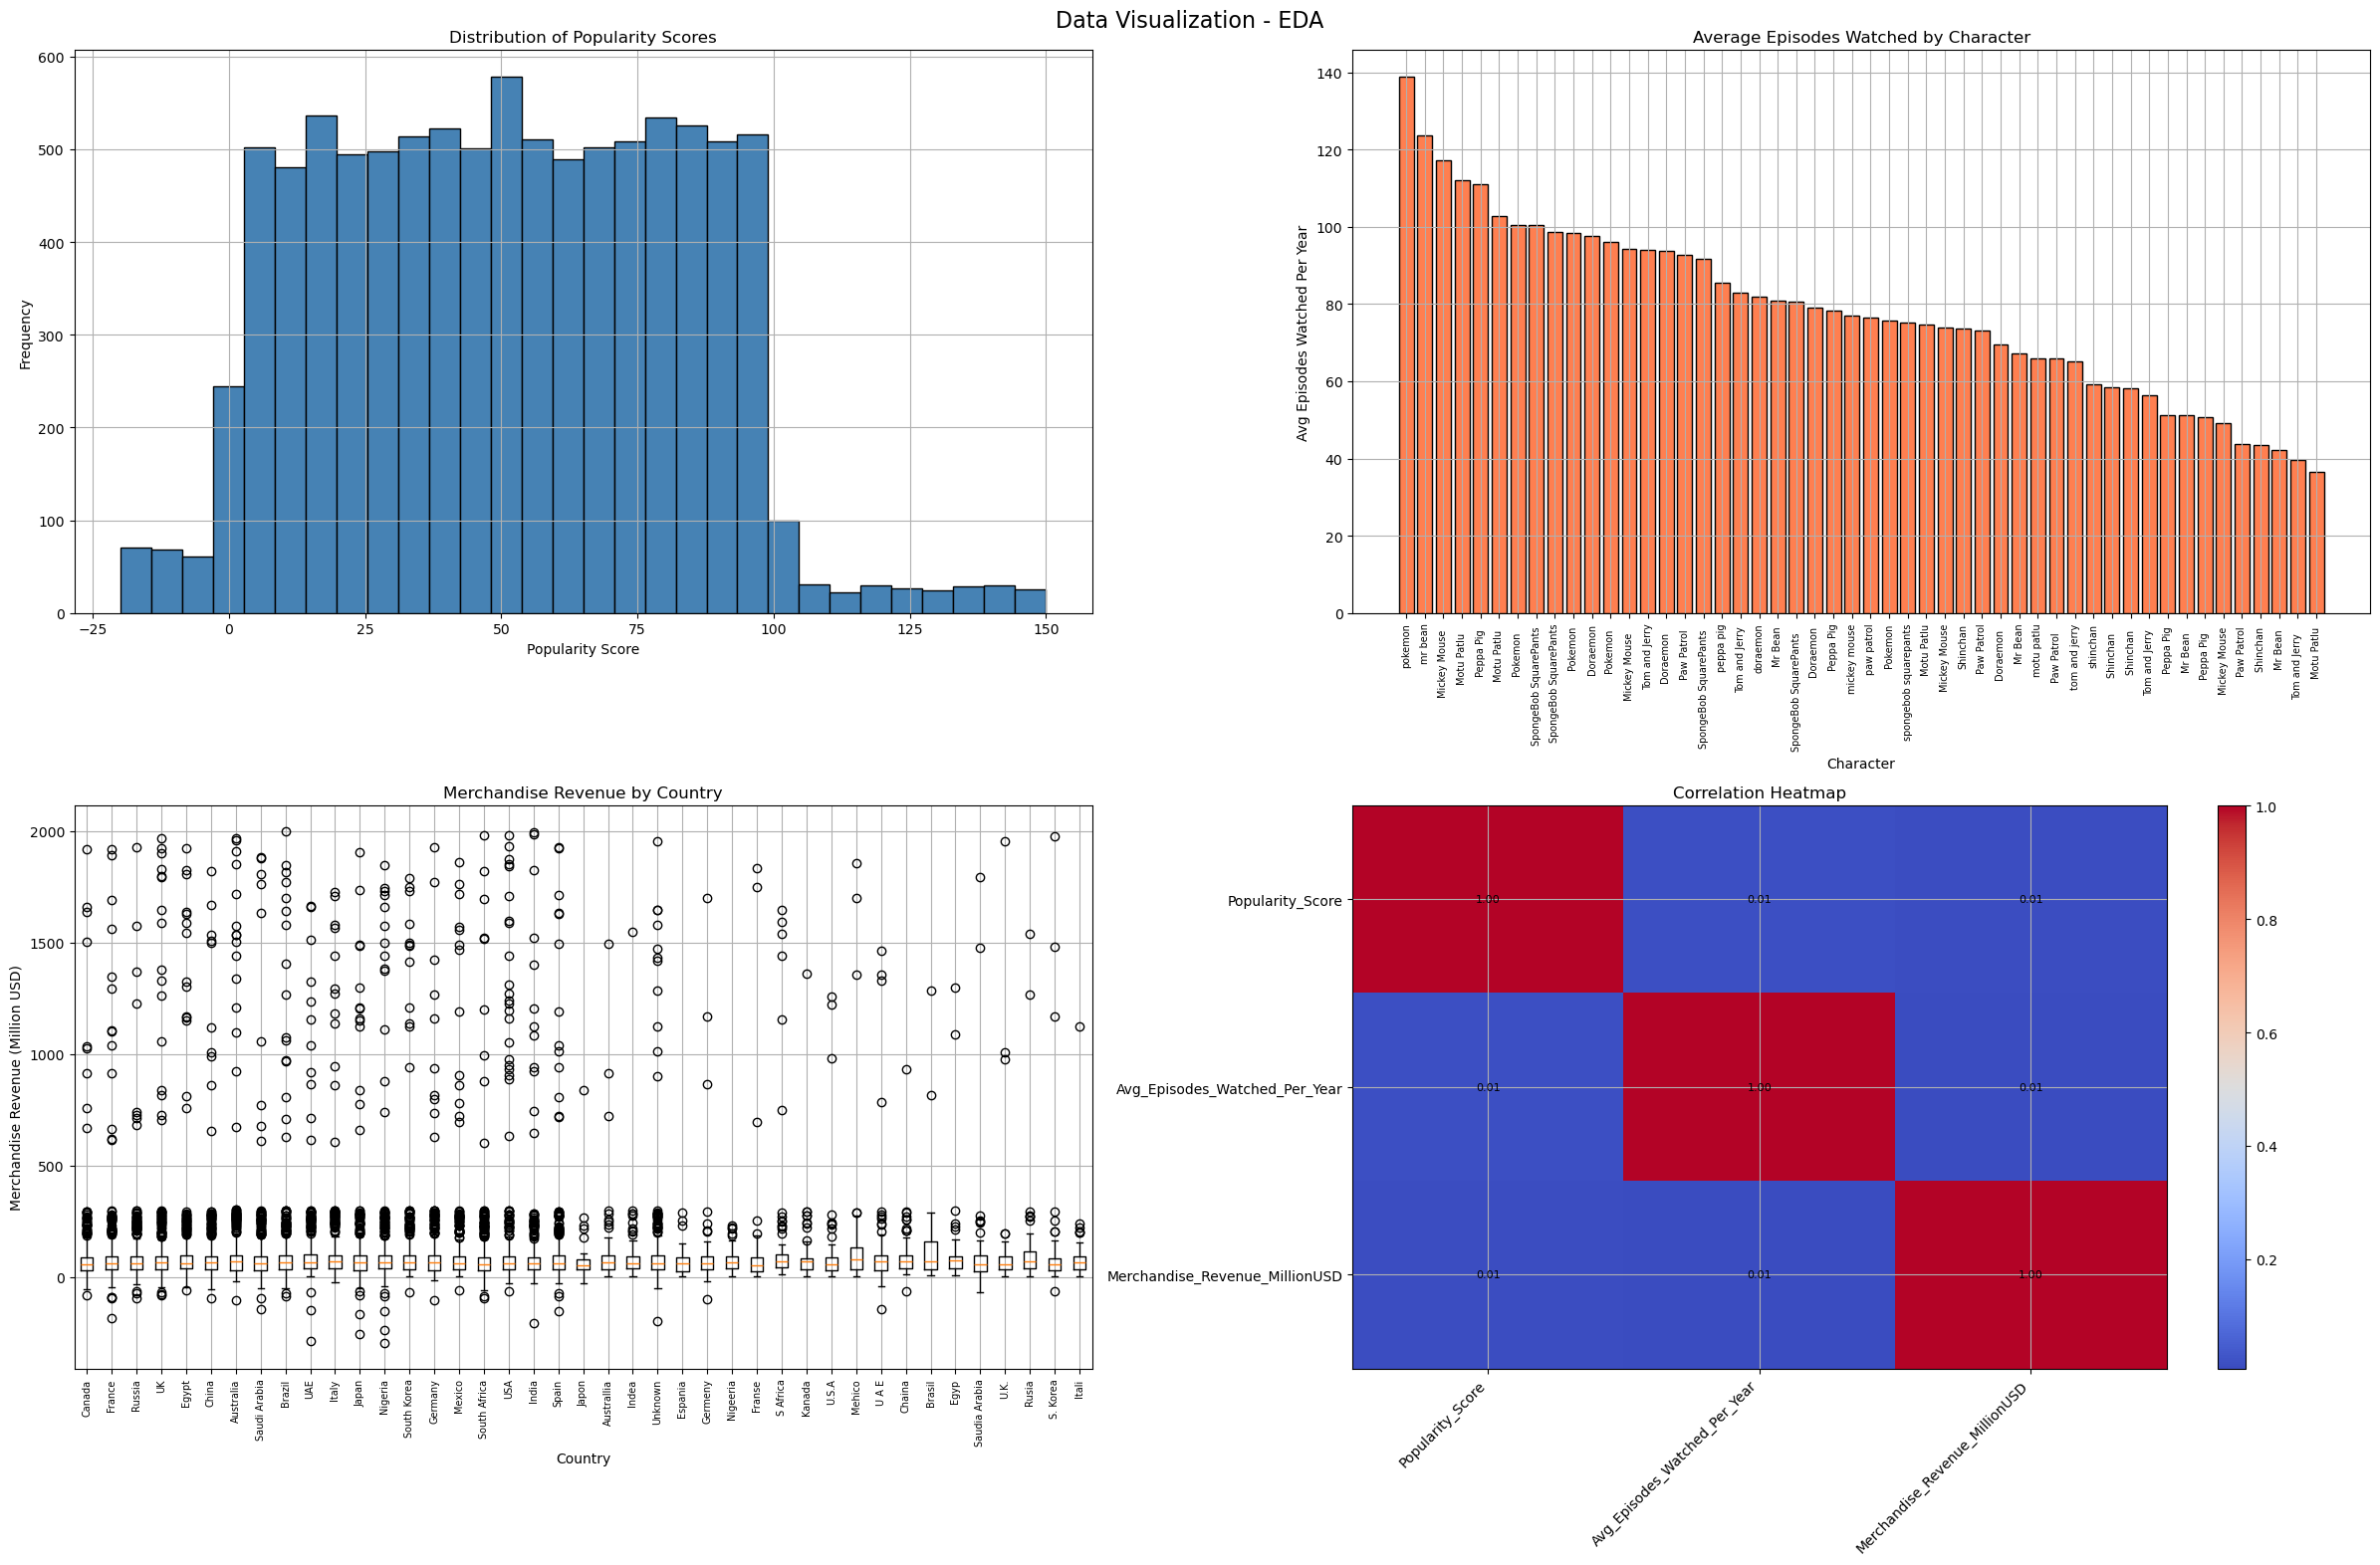

In [6]:
# Temporary conversion for visualization only - df stays raw for Task 1.3
pop = pd.to_numeric(df['Popularity_Score'], errors='coerce')
eps = pd.to_numeric(df['Avg_Episodes_Watched_Per_Year'], errors='coerce')
rev = pd.to_numeric(df['Merchandise_Revenue_MillionUSD'], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(24, 16))
fig.suptitle('Data Visualization - EDA', fontsize=16)

# 1. Distribution of popularity scores (histogram)
axes[0, 0].hist(pop.dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Popularity Scores')
axes[0, 0].set_xlabel('Popularity Score')
axes[0, 0].set_ylabel('Frequency')

# 2. Average episodes watched by character (bar chart)
temp_df = df.copy()
temp_df['Avg_Episodes_Watched_Per_Year'] = eps
avg_episodes = temp_df.groupby('Character')['Avg_Episodes_Watched_Per_Year'].mean().sort_values(ascending=False)
axes[0, 1].bar(avg_episodes.index, avg_episodes.values, color='coral', edgecolor='black')
axes[0, 1].set_title('Average Episodes Watched by Character')
axes[0, 1].set_xlabel('Character')
axes[0, 1].set_ylabel('Avg Episodes Watched Per Year')
axes[0, 1].tick_params(axis='x', rotation=90, labelsize=7)

# 3. Merchandise revenue by country (box plot)
temp_df['Merchandise_Revenue_MillionUSD'] = rev
countries = temp_df['Country'].dropna().unique()
data_by_country = [temp_df[temp_df['Country'] == c]['Merchandise_Revenue_MillionUSD'].dropna().values for c in countries]
axes[1, 0].boxplot(data_by_country, labels=countries)
axes[1, 0].set_title('Merchandise Revenue by Country')
axes[1, 0].set_xlabel('Country')
axes[1, 0].set_ylabel('Merchandise Revenue (Million USD)')
axes[1, 0].tick_params(axis='x', rotation=90, labelsize=7)

# 4. Correlation heatmap
numerical_cols = pd.DataFrame({'Popularity_Score': pop, 'Avg_Episodes_Watched_Per_Year': eps, 'Merchandise_Revenue_MillionUSD': rev})
corr = numerical_cols.corr().values
col_names = numerical_cols.corr().columns.tolist()
im = axes[1, 1].imshow(corr, cmap='coolwarm', aspect='auto')
axes[1, 1].set_xticks(range(len(col_names)))
axes[1, 1].set_yticks(range(len(col_names)))
axes[1, 1].set_xticklabels(col_names, rotation=45, ha='right')
axes[1, 1].set_yticklabels(col_names)
for i in range(len(col_names)):
    for j in range(len(col_names)):
        axes[1, 1].text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=8)
axes[1, 1].set_title('Correlation Heatmap')
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()

### Task 1.3: Identifying Data Issues

Based on your exploration:
- List all data quality issues you've found
- Categorize them (missing values, outliers, inconsistent formats, etc.)
- Explain how each issue might affect your analysis

In [12]:
print("ISSUE 1: Wrong Data Types")
print(df.dtypes)

print("\nISSUE 2: Missing Values")
print(df.isnull().sum())

print("\nISSUE 3: 'Unknown' String Instead of NaN")
print(f"'Unknown' in Popularity_Score: {(df['Popularity_Score'] == 'Unknown').sum()}")
print(f"'Unknown' in Avg_Episodes_Watched_Per_Year: {(df['Avg_Episodes_Watched_Per_Year'] == 'Unknown').sum()}")

print("\nISSUE 4: Dollar Signs in Revenue Column")
dollar_rows = df['Merchandise_Revenue_MillionUSD'].astype(str).str.contains(r'\$', na=False)
print(f"Rows with '$' symbol: {dollar_rows.sum()}")
print(df[dollar_rows]['Merchandise_Revenue_MillionUSD'].head(5))

print("\nISSUE 5: Popularity Scores Outside Valid Range (0-100)")
temp_popularity = pd.to_numeric(df['Popularity_Score'], errors='coerce')
out_of_range = df[(temp_popularity < 0) | (temp_popularity > 100)]
print(f"Rows outside 0-100: {len(out_of_range)}")
print(out_of_range[['Character', 'Country', 'Popularity_Score']].head(5))

print("\nISSUE 6: Negative Values in Revenue and Episodes")
temp_revenue = pd.to_numeric(df['Merchandise_Revenue_MillionUSD'], errors='coerce')
temp_episodes = pd.to_numeric(df['Avg_Episodes_Watched_Per_Year'], errors='coerce')
neg = df[(temp_revenue < 0) | (temp_episodes < 0)]
print(f"Rows with negative values: {len(neg)}")
print(neg[['Character', 'Country', 'Merchandise_Revenue_MillionUSD', 'Avg_Episodes_Watched_Per_Year']].head(5))

print("\nISSUE 7: Inconsistent Country Names")
print(sorted(df['Country'].dropna().unique()))

print("\nISSUE 8: Inconsistent Character Names")
print(sorted(df['Character'].dropna().unique()))

ISSUE 1: Wrong Data Types
Character                          object
Country                            object
Popularity_Score                  float64
Avg_Episodes_Watched_Per_Year     float64
Merchandise_Revenue_MillionUSD    float64
dtype: object

ISSUE 2: Missing Values
Character                           0
Country                           447
Popularity_Score                  513
Avg_Episodes_Watched_Per_Year     144
Merchandise_Revenue_MillionUSD    168
dtype: int64

ISSUE 3: 'Unknown' String Instead of NaN
'Unknown' in Popularity_Score: 0
'Unknown' in Avg_Episodes_Watched_Per_Year: 0

ISSUE 4: Dollar Signs in Revenue Column
Rows with '$' symbol: 0
Series([], Name: Merchandise_Revenue_MillionUSD, dtype: float64)

ISSUE 5: Popularity Scores Outside Valid Range (0-100)
Rows outside 0-100: 453
         Character    Country  Popularity_Score
179        Pokemon     Brazil        110.913592
351  Tom and Jerry    Germany         -8.116246
368  Tom and Jerry      Egypt        148.956115

## Part 2: Data Cleaning and Preprocessing

### Task 2.1: Handling Missing Values

Implement strategies to handle missing values in the dataset:

- For categorical columns: Replace with mode or a placeholder
- For numerical columns: Replace with mean, median, or a calculated value
- Document your approach and justify your choices

In [13]:

df['Popularity_Score'] = pd.to_numeric(df['Popularity_Score'], errors='coerce')
df['Avg_Episodes_Watched_Per_Year'] = pd.to_numeric(df['Avg_Episodes_Watched_Per_Year'], errors='coerce')
df['Merchandise_Revenue_MillionUSD'] = pd.to_numeric(df['Merchandise_Revenue_MillionUSD'], errors='coerce')

df['Country'].fillna(df['Country'].mode()[0], inplace=True)

df['Popularity_Score'].fillna(df['Popularity_Score'].median(), inplace=True)
df['Avg_Episodes_Watched_Per_Year'].fillna(df['Avg_Episodes_Watched_Per_Year'].median(), inplace=True)
df['Merchandise_Revenue_MillionUSD'].fillna(df['Merchandise_Revenue_MillionUSD'].median(), inplace=True)

print("Missing values after fix:")
print(df.isnull().sum())

Missing values after fix:
Character                         0
Country                           0
Popularity_Score                  0
Avg_Episodes_Watched_Per_Year     0
Merchandise_Revenue_MillionUSD    0
dtype: int64


/var/folders/l7/4qmv1ff116nbd017vb1kny5r0000gn/T/ipykernel_11109/4255006134.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Country'].fillna(df['Country'].mode()[0], inplace=True)
/var/folders/l7/4qmv1ff116nbd017vb1kny5r0000gn/T/ipykernel_11109/4255006134.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting 

### Task 2.2: Handling Inconsistent Data

Fix inconsistencies in the dataset:

- Standardize character names (capitalization, extra spaces)
- Correct country name spellings
- Convert any string values in numerical columns to appropriate numeric types

In [14]:


df['Character'] = df['Character'].str.strip().str.title()

df['Country'] = df['Country'].str.strip().str.title()

country_corrections = {
    'U.K.': 'UK',
    'U.S.A': 'USA',
    'Germeny': 'Germany',
    'Nigeeria': 'Nigeria',
    'Australlia': 'Australia',
    'Indea': 'India',
    'Japon': 'Japan',
    'Franse': 'France',
    'Kanada': 'Canada',
    'Mehico': 'Mexico',
    'U A E': 'UAE',
    'Chaina': 'China',
    'Brasil': 'Brazil',
    'Egyp': 'Egypt',
    'Saudia Arabia': 'Saudi Arabia',
    'S. Korea': 'South Korea',
    'Itali': 'Italy',
    'Rusia': 'Russia',
    'S Africa': 'South Africa',
    'Espania': 'Spain',
    'Unknown': 'Unknown'
}
df['Country'] = df['Country'].replace(country_corrections)

df['Merchandise_Revenue_MillionUSD'] = df['Merchandise_Revenue_MillionUSD'].astype(str).str.replace('$', '', regex=False)
df['Merchandise_Revenue_MillionUSD'] = pd.to_numeric(df['Merchandise_Revenue_MillionUSD'], errors='coerce')

print("Unique characters after fix:")
print(sorted(df['Character'].unique()))
print(f"\nUnique countries after fix: {df['Country'].nunique()}")
print(sorted(df['Country'].unique()))

Unique characters after fix:
['Doraemon', 'Mickey Mouse', 'Motu Patlu', 'Mr Bean', 'Paw Patrol', 'Peppa Pig', 'Pokemon', 'Shinchan', 'Spongebob Squarepants', 'Tom And Jerry']

Unique countries after fix: 24
['Australia', 'Brazil', 'Canada', 'China', 'Egypt', 'France', 'Germany', 'India', 'Italy', 'Japan', 'Mexico', 'Nigeria', 'Russia', 'Saudi Arabia', 'South Africa', 'South Korea', 'Spain', 'UAE', 'UK', 'USA', 'Uae', 'Uk', 'Unknown', 'Usa']


### Task 2.3: Outlier Detection and Handling

Detect and handle outliers in numerical columns:

- Use visualization methods (box plots) to identify outliers
- Use statistical methods (Z-score or IQR) to confirm outliers
- Implement an appropriate strategy (capping, removing, or transforming)

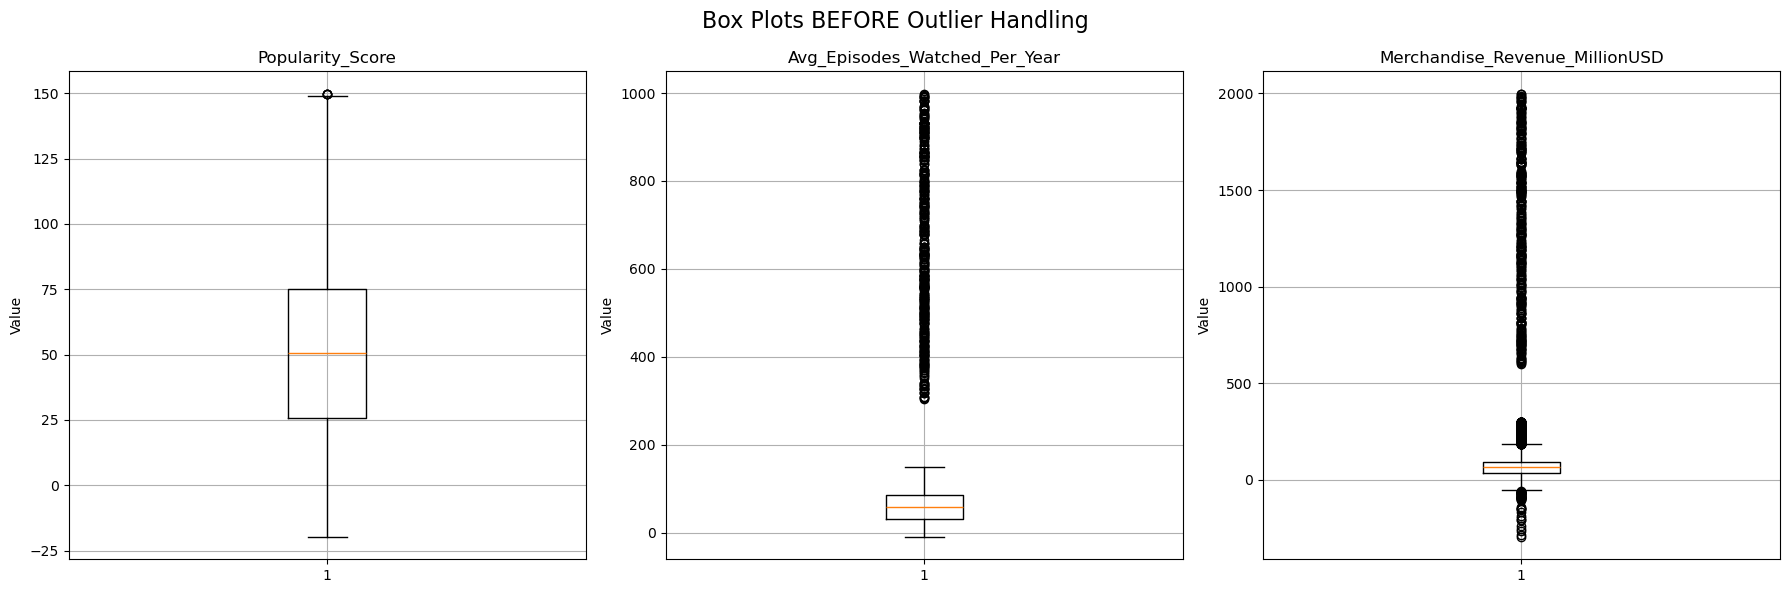

IQR Outlier Analysis

Popularity_Score:
  Q1=25.82, Q3=75.25, IQR=49.44
  IQR Valid range: [-48.34, 149.41]
  Outliers found: 4

Avg_Episodes_Watched_Per_Year:
  Q1=31.50, Q3=86.00, IQR=54.50
  IQR Valid range: [-50.25, 167.75]
  Outliers found: 365

Merchandise_Revenue_MillionUSD:
  Q1=33.23, Q3=93.44, IQR=60.21
  IQR Valid range: [-57.09, 183.75]
  Outliers found: 1331

Outliers capped successfully!


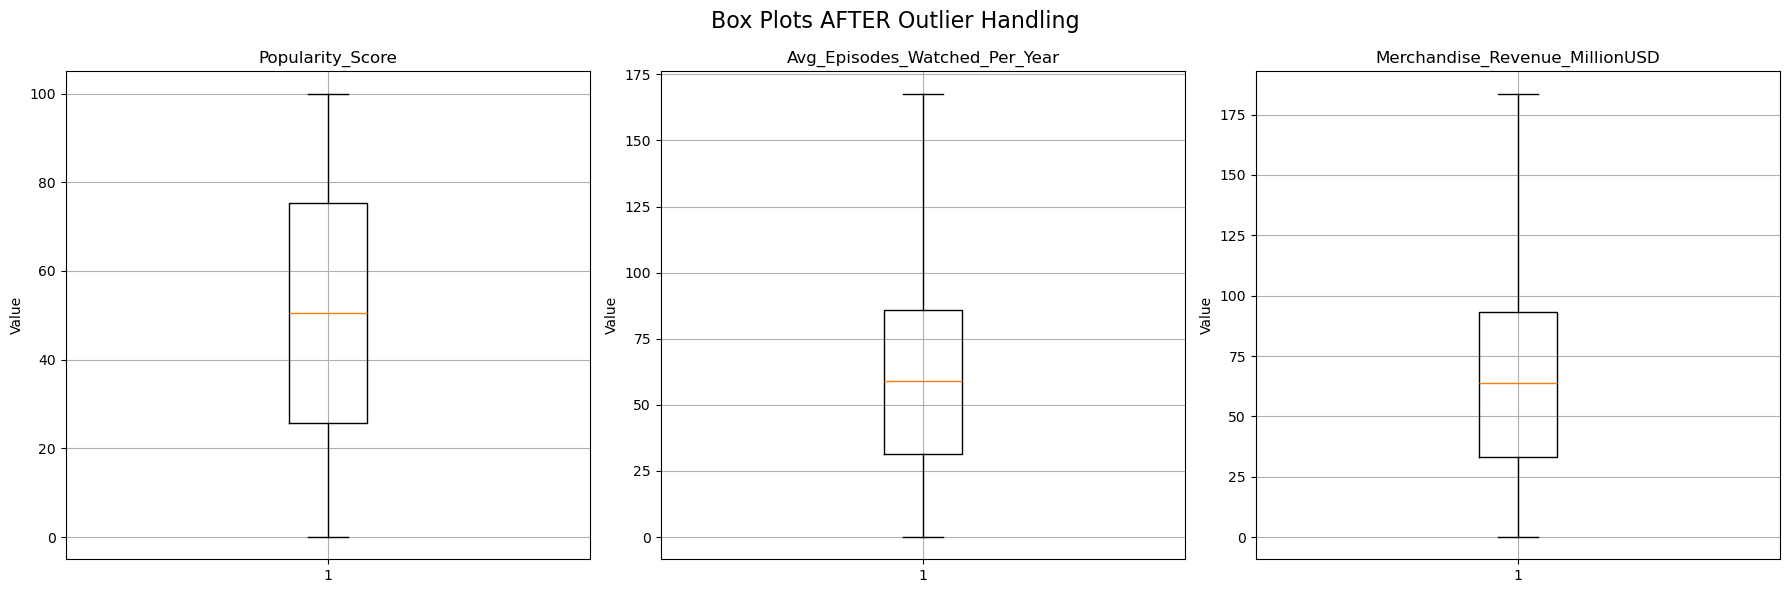


Describe after capping:
       Popularity_Score  Avg_Episodes_Watched_Per_Year  \
count      10000.000000                   10000.000000   
mean          50.417689                      62.762225   
std           29.275905                      39.518973   
min            0.000000                       0.000000   
25%           25.816413                      31.500000   
50%           50.463176                      59.000000   
75%           75.254013                      86.000000   
max          100.000000                     167.750000   

       Merchandise_Revenue_MillionUSD  
count                    10000.000000  
mean                        74.335216  
std                         54.373741  
min                          0.000000  
25%                         33.226264  
50%                         63.787636  
75%                         93.435565  
max                        183.749515  


In [15]:

cols = ['Popularity_Score', 'Avg_Episodes_Watched_Per_Year', 'Merchandise_Revenue_MillionUSD']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Box Plots BEFORE Outlier Handling', fontsize=16)
for i, col in enumerate(cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')
plt.tight_layout()
plt.show()

print("=" * 60)
print("IQR Outlier Analysis")
print("=" * 60)
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  IQR Valid range: [{lower:.2f}, {upper:.2f}]")
    print(f"  Outliers found: {len(outliers)}")

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

df['Popularity_Score'] = df['Popularity_Score'].clip(lower=0, upper=100)
df['Avg_Episodes_Watched_Per_Year'] = df['Avg_Episodes_Watched_Per_Year'].clip(lower=0)
df['Merchandise_Revenue_MillionUSD'] = df['Merchandise_Revenue_MillionUSD'].clip(lower=0)

print("\nOutliers capped successfully!")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Box Plots AFTER Outlier Handling', fontsize=16)
for i, col in enumerate(cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')
plt.tight_layout()
plt.show()

print("\nDescribe after capping:")
print(df[cols].describe())

### Task 2.4: Data Transformation

Apply appropriate transformations to prepare the data for analysis:

- Standardize or normalize numerical features if needed
- Create any useful derived features
- Encode categorical variables if necessary

In [16]:


from sklearn.preprocessing import MinMaxScaler

cols = ['Popularity_Score', 'Avg_Episodes_Watched_Per_Year', 'Merchandise_Revenue_MillionUSD']

scaler = MinMaxScaler()
df[cols] = scaler.fit_transform(df[cols])

print("After Min-Max Normalization:")
print(df[cols].describe())

df['Popularity_Tier'] = pd.cut(
    df['Popularity_Score'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low', 'Medium', 'High']
)

df['Revenue_Per_Episode'] = df['Merchandise_Revenue_MillionUSD'] / (df['Avg_Episodes_Watched_Per_Year'] + 0.001)

print("\nDerived features added:")
print(df[['Character', 'Popularity_Tier', 'Revenue_Per_Episode']].head(10))

df['Character_encoded'] = df['Character'].astype('category').cat.codes
df['Country_encoded'] = df['Country'].astype('category').cat.codes

print("\nEncoded columns:")
print(df[['Character', 'Character_encoded', 'Country', 'Country_encoded']].head(10))

print("\nFinal dataframe shape:", df.shape)
print("\nFinal dtypes:")
print(df.dtypes)

After Min-Max Normalization:
       Popularity_Score  Avg_Episodes_Watched_Per_Year  \
count      10000.000000                   10000.000000   
mean           0.504177                       0.374141   
std            0.292759                       0.235583   
min            0.000000                       0.000000   
25%            0.258164                       0.187779   
50%            0.504632                       0.351714   
75%            0.752540                       0.512668   
max            1.000000                       1.000000   

       Merchandise_Revenue_MillionUSD  
count                    10000.000000  
mean                         0.404546  
std                          0.295912  
min                          0.000000  
25%                          0.180824  
50%                          0.347145  
75%                          0.508494  
max                          1.000000  

Derived features added:
               Character Popularity_Tier  Revenue_Per_Episode
0

## Part 3: Advanced Analysis (Optional)

### Task 3.1: Multicollinearity Analysis using VIF

Variance Inflation Factor (VIF) helps identify correlated features in your dataset:

> You'll need to install statsmodels first: `pip install statsmodels`

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a new dataframe with only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_df.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_df.values, i) for i in range(len(numeric_df.columns))]

print(vif_data)

> **Note**: VIF values > 5 indicate high multicollinearity. [Learn more about VIF here](https://www.geeksforgeeks.org/detecting-multicollinearity-with-vif-python/)

### Task 3.2: Dimensionality Reduction with PCA (Optional)

If you'd like to explore dimensionality reduction:
> **Note**: [Learn more about PCA here](https://www.kaggle.com/code/vipulgandhi/pca-beginner-friendly-detailed-explanation)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# Apply PCA
pca = PCA()
pca_data = pca.fit_transform(scaled_data)

# Create a scree plot
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Components')
plt.grid(True)
plt.show()

## Part 4: Conclusion and Documentation

### Task 4.1: Summarize Your Findings

Write a summary of:
- The initial state of the data
- All issues identified
- Methods used to address each issue
- The final state of the cleaned dataset
- Any insights gained during the process

### Task 4.2: Save Your Cleaned Dataset

Save your cleaned and preprocessed dataset:

Task 4.1
The initial state of the data was found to be very messy with lots of data missing as well. The initial data types of 3 of the columns which were supposed to be floats were instead saved as object. for some data which was not known, the data was saved as "unknown" which again confuses the compiler and hence had to be changed to NaN. A lot of duplicate columns were also found. For example, U.S.A and USA were assumed to be 2 different things , even the spacing was different in certain columns, for example "doraemon" and "  doraemon" were saved as 2 different things. the strip function had to be used to fix that. Even certain things like revenue were saved to be negative which is again not possible. Popularity score also was allowed to be only between 1 and 100, but that was not the case when looked at the data. For the missing values, if the missing value belonged to the float data type was replaced by median . If it was not float it was replaced by the mode. Finally there were a lot of values which were not conitiguous with the data and hence had to be clipped according using the IQR analysis . Lastly , the data was normalized so that the ml model dosent give more importance to one factor when compared to the other.

In [6]:
# TODO: Your code here


# END OF TODO
df_cleaned.to_csv('cartoon_popularity_cleaned.csv', index=False)

NameError: name 'df_cleaned' is not defined

## Submission Guidelines

1. Submit your completed Jupyter notebook (.ipynb file)
2. Include the original and cleaned datasets
3. Make sure all code cells are executed and outputs are visible
4. Add appropriate markdown cells explaining your approach and findings
5. Ensure your notebook is well-organized and follows a logical flow



## Resources

### Pandas and Data Manipulation
- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [10 Minutes to Pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
- [Kaggle: Pandas Tutorial](https://www.kaggle.com/learn/pandas)

### Data Visualization
- [Matplotlib Documentation](https://matplotlib.org/stable/contents.html)
- [Matplotlib Gallery](https://matplotlib.org/stable/gallery/index.html)
- [Kaggle: Data Visualization](https://www.kaggle.com/learn/data-visualization)

### Data Cleaning and Preprocessing
- [Handling Missing Values](https://towardsdatascience.com/data-cleaning-with-python-and-pandas-detecting-missing-values-3e9c6ebcf78b)
- [Outlier Detection Methods](https://machinelearningmastery.com/how-to-use-statistics-to-identify-outliers-in-data/)
- [GeeksforGeeks: Data Preprocessing](https://www.geeksforgeeks.org/data-preprocessing-in-data-mining/)

### Advanced Topics
- [Understanding VIF](https://www.geeksforgeeks.org/detecting-multicollinearity-with-vif-python/)
- [PCA Explained](https://www.kaggle.com/code/vipulgandhi/pca-beginner-friendly-detailed-explanation)

---

**Good luck with your assignment! Remember, data preprocessing is an art as much as it is a science – there are often multiple valid approaches to handle data issues, so freely use your intution wherever you need.**